# S1 Feature Matrix + Redundancy Screen

Builds the production candidate feature matrix for the S1 equities sleeve from the frozen keep-list (H-001 / H-004 / H-005 / H-006 / H-008 survivors plus H-009 GDELT, H-010 short flow / filing clock, and complementary beta / volume / Amihud columns). Engineers all columns on the **full** census panel, screens redundancy on **research IS only**, then exports a lean full-sample parquet after an editable ditch list.

## Paths

| Artifact | Path |
|----------|------|
| Full panel (input) | `01_data/data_files/s1_equities/s1_factor_panel_full.parquet` |
| Train panel (IS dates only) | `01_data/data_files/s1_equities/s1_factor_panel_train.parquet` |
| Raw engineered cache | `01_data/cache/s1_feature_matrix_raw.parquet` |
| **Final export** | `01_data/data_files/s1_equities/s1_engineered_features.parquet` |

**Final export columns:** `date`, `ticker`, `feature_date` + OHLCV + `fwd_ret_*` labels + kept engineered factors. Context columns are retained for downstream models; redundancy ditch lists only remove engineered features.

## Sample discipline

- Engineer on the **full** panel so holdout rows receive the same PIT features.
- Correlation / VIF / coverage run only where `date` is in the train parquet’s date set (aligned to `s1_factor_panel.ipynb` — no hard-coded `0.70`).
- Fill staged ditch lists after each §4 diagnostic (`cols_remove_coverage`, `cols_remove_corr`, `cols_remove_vif`; no overlaps). §5 unions them into `cols_to_remove` and exports the matrix (context + kept factors).

## Multi-param family rule

Store kwargs apply to the whole call. This notebook calls each family dispatcher **once per target column** with `feature_subset=[that_id]` and that column’s windows, then renames bare store stems to the spreadsheet names when needed.

## Cache rebuild

After changing `FEATURE_COLS` or merge logic, **delete** `01_data/cache/s1_feature_matrix_raw.parquet` or set `FORCE_REBUILD = True` once so FINRA / filing clock / GDELT / new factors rebuild. A stale cache missing new columns also falls through to a cold build automatically.

Cold builds show **`S1 matrix fetch`** (data stages) and **`S1 matrix factors`** (per-column engineering) tqdm bars on stderr; per-factor `built …` confirmations are not printed.

TA-Lib factors are **not** included (weak 5d IC/ICIR on the separate screen).


## 0. Imports & Config

Resolve the repo root; configure panel / cache / export paths and `FEATURE_COLS`. Staged ditch lists are filled in §4 after each diagnostic; §5 builds `cols_to_remove`. Set `FORCE_REBUILD = True` to ignore the raw engineered cache.


In [1]:
from __future__ import annotations

import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

# Jupyter cwd is often this notebook's folder, not the repo root; walk up until we find 01_data/ingestion.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from data.ingestion.alternative_data.fama_french_fetcher import fetch_ff_factors_daily
from data.ingestion.alternative_data.finra_short_volume import fetch_short_volume_daily
from data.ingestion.alternative_data.sec_companyfacts import (
    fetch_filing_clock_daily,
    fetch_gross_profitability_daily,
    fetch_size_value_daily,
)
from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.feature_implementation.beta_features import market_return_frame
from data.processing.feature_implementation.momentum import add_raw_momentum
from data.processing.feature_store import (
    add_beta_factors,
    add_gdelt_sentiment_factors,
    add_gross_profitability_factors,
    add_near_52w_factors,
    add_obv_momentum_factors,
    add_short_flow_factors,
    add_size_value_factors,
    add_volume_factors,
    drop_beta_workspace,
)

FULL_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_full.parquet"
)
TRAIN_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_train.parquet"
)
RAW_CACHE_PATH = os.path.join(
    ROOT, "01_data", "cache", "s1_feature_matrix_raw.parquet"
)
OUTPUT_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_engineered_features.parquet"
)
GP_SEC_CACHE_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_h008_gp_sec.parquet"
)
SHORT_FLOW_CACHE_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_h010_short_flow.parquet"
)
FILING_CLOCK_CACHE_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_h010_filing_clock.parquet"
)

FORCE_REBUILD = False
BENCHMARK = "RSP"
UNIVARIATE_BENCHMARK = BENCHMARK.lower()
if UNIVARIATE_BENCHMARK not in ("spy", "rsp"):
    raise ValueError(f"BENCHMARK must be 'SPY' or 'RSP', got {BENCHMARK!r}")

FFILL_LIMIT = 5  # business days for sparse SEC fundamentals
CORR_THRESH_HIGH = 0.70
CORR_THRESH_VERY_HIGH = 0.90

FEATURE_COLS = [
    "raw_momentum_252_5",
    "obv_mom_soft_126_21_20",
    "smart_residual_mom_189_42",
    "rel_downside_beta_252",
    "rel_upside_beta_63",
    "net_beta_spread_63",
    "smart_residual_mom_189_21",
    "smart_beta_smb_84",
    "smart_beta_hml_252",
    "downside_beta_42",
    "smart_beta_mom_126",
    "upside_beta_42",
    "near_52w_ratio_252_raw",
    "near_52w_log_drawdown_252_raw",
    "size_mom_126",
    "val_roc_pb_252",
    "val_roc_pe_252",
    "val_mom_interact_252_21",
    "earnings_yield",
    "log_mcap",
    "val_mom_dist_252_21",
    "val_mom_resid_126_252_10",
    "gross_profitability",
    "filing_clock_expected_until",
    "filing_clock_since",
    "short_flow_ratio",
    "short_flow_abnormal_1_120",
    "market_corr",
    "r_squared",
    "rel_strength",
    "beta_mkt_interact",
    "mkt_ret",
    "mkt_vol",
    "mkt_near_52w",
    "amihud",
    "abnormal_volume",
    "gdelt_tone_x_attention_21",
    "gdelt_tone_21",
    "gdelt_attention_5",
    "gdelt_abnormal_attention_5_60",
]

KEY_COLS = ["date", "ticker", "feature_date"]
CONTEXT_COLS = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "fwd_ret_1",
    "fwd_ret_5",
    "fwd_ret_21",
]

print(f"ROOT={ROOT}")
print(f"FORCE_REBUILD={FORCE_REBUILD}  BENCHMARK={BENCHMARK}")
print(f"FEATURE_COLS={len(FEATURE_COLS)}")
print(f"RAW_CACHE_PATH={RAW_CACHE_PATH}")
print(f"OUTPUT_PATH={OUTPUT_PATH}")


ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
FORCE_REBUILD=False  BENCHMARK=RSP
FEATURE_COLS=40
RAW_CACHE_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\cache\s1_feature_matrix_raw.parquet
OUTPUT_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet


## 1. Data Loading

### Cache contract

1. If `FORCE_REBUILD` is False **and** `s1_feature_matrix_raw.parquet` exists with all `FEATURE_COLS` → **CACHE HIT**: load it; skip fetch / engineering.
2. Otherwise → **CACHE MISS**: load `s1_factor_panel_full.parquet`, merge RSP market returns / OHLCV, ETF Carhart proxies, SEC size/value, GP, FINRA short volume, and filing-clock anchors on `feature_date`. GDELT tone/article counts are attached later inside `add_gdelt_sentiment_factors` (store auto-fetch).

Cold builds show an **`S1 matrix fetch`** tqdm stage bar (stderr). FINRA may nest its own month bar underneath. After extending `FEATURE_COLS`, delete the raw cache or set `FORCE_REBUILD = True` once so new merges run.

IS dates always come from `s1_factor_panel_train.parquet` (even on a cache hit).


In [2]:
def _ffill_by_ticker(frame: pd.DataFrame, cols: list[str], limit: int) -> pd.DataFrame:
    out = frame.copy()
    present = [c for c in cols if c in out.columns]
    if not present:
        return out
    out = out.sort_values(["ticker", "date"])
    out[present] = out.groupby("ticker", sort=False)[present].ffill(limit=limit)
    return out


def _rename_stem(frame: pd.DataFrame, stem: str, target: str) -> pd.DataFrame:
    """Rename bare store stem to spreadsheet name; no-op if target already present."""
    if target in frame.columns:
        if stem in frame.columns and stem != target:
            return frame.drop(columns=[stem])
        return frame
    if stem not in frame.columns:
        raise ValueError(
            f"expected store column {stem!r} to rename to {target!r}; "
            f"neither present. cols sample={list(frame.columns)[-20:]}"
        )
    return frame.rename(columns={stem: target})


train_dates = pd.Index(
    pd.to_datetime(pd.read_parquet(TRAIN_PANEL_PATH, columns=["date"])["date"])
    .dropna()
    .unique()
).sort_values()
print(
    f"IS dates from train parquet: {train_dates[0].date()} -> {train_dates[-1].date()} "
    f"({len(train_dates):,} dates)"
)

use_raw_cache = (
    (not FORCE_REBUILD)
    and os.path.isfile(RAW_CACHE_PATH)
)
panel = None
market_returns = None
market_ohlcv = None
ff_factors = None

if use_raw_cache:
    panel = pd.read_parquet(RAW_CACHE_PATH)
    panel["date"] = pd.to_datetime(panel["date"])
    if "feature_date" in panel.columns:
        panel["feature_date"] = pd.to_datetime(panel["feature_date"])
    missing = [c for c in FEATURE_COLS if c not in panel.columns]
    if missing:
        print(f"CACHE STALE: missing {missing} — falling back to cold build")
        use_raw_cache = False
        panel = None
    else:
        print(
            f"CACHE HIT: {RAW_CACHE_PATH}\n"
            f"rows={len(panel):,}  tickers={panel['ticker'].nunique()}  "
            f"dates={panel['date'].nunique():,}  "
            f"[{panel['date'].min().date()} -> {panel['date'].max().date()}]"
        )

if not use_raw_cache:
    tickers = None
    start = None
    end = None
    price_for_sec = None

    fetch_stages = [
        "load_panel",
        "market_ff",
        "size_value",
        "gross_profitability",
        "finra_short",
        "filing_clock",
        "ffill",
    ]
    for stage in tqdm(
        fetch_stages, desc="S1 matrix fetch", unit="stage", file=sys.stderr
    ):
        if stage == "load_panel":
            panel = pd.read_parquet(FULL_PANEL_PATH)
            panel["date"] = pd.to_datetime(panel["date"])
            panel["feature_date"] = pd.to_datetime(panel["feature_date"])
            panel["ticker"] = panel["ticker"].astype(str).str.strip().str.upper()
            tickers = sorted(panel["ticker"].unique().tolist())
            start = panel["date"].min()
            end = panel["date"].max()
            print(
                f"CACHE MISS: loaded {FULL_PANEL_PATH}\n"
                f"rows={len(panel):,}  tickers={len(tickers)}  "
                f"[{start.date()} -> {end.date()}]"
            )
        elif stage == "market_ff":
            market_ohlcv = fetch_ohlcv(
                BENCHMARK, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")
            )
            market_returns = market_return_frame(market_ohlcv)
            ff_factors = fetch_ff_factors_daily(
                start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")
            )
            print(f"{BENCHMARK} market returns: {len(market_returns):,} rows")
            print(
                f"FF factors: {len(ff_factors):,} rows  cols={list(ff_factors.columns)}"
            )
        elif stage == "size_value":
            price_for_sec = (
                panel[["feature_date", "ticker", "close"]]
                .rename(columns={"feature_date": "date"})
                .dropna(subset=["date"])
            )
            sv = fetch_size_value_daily(
                tickers,
                start_date=start.date(),
                end_date=end.date(),
                price_panel=price_for_sec,
            )
            sv["date"] = pd.to_datetime(sv["date"])
            sv["ticker"] = sv["ticker"].astype(str).str.strip().str.upper()
            sv = sv.rename(columns={"date": "feature_date"})
            sv_cols = [
                "feature_date",
                "ticker",
                "shares_outstanding",
                "book_equity",
                "eps_ttm",
                "market_cap",
                "pe",
                "pb",
            ]
            panel = panel.merge(sv[sv_cols], on=["feature_date", "ticker"], how="left")
            print(
                f"SV merge: market_cap non-null={panel['market_cap'].notna().mean():.1%}  "
                f"pe={panel['pe'].notna().mean():.1%}  pb={panel['pb'].notna().mean():.1%}"
            )
        elif stage == "gross_profitability":
            gp_sec = fetch_gross_profitability_daily(
                tickers,
                start_date=start.date(),
                end_date=end.date(),
                price_panel=price_for_sec,
            )
            gp_sec["date"] = pd.to_datetime(gp_sec["date"])
            gp_sec["ticker"] = gp_sec["ticker"].astype(str).str.strip().str.upper()
            os.makedirs(os.path.dirname(GP_SEC_CACHE_PATH), exist_ok=True)
            gp_sec.to_parquet(GP_SEC_CACHE_PATH, index=False)
            print(f"Wrote GP SEC cache: {GP_SEC_CACHE_PATH}")
            gp_sec = gp_sec.rename(columns={"date": "feature_date"})
            gp_cols = [
                "feature_date",
                "ticker",
                "gross_profit_ttm",
                "assets",
                "gp_asset",
            ]
            panel = panel.merge(
                gp_sec[gp_cols], on=["feature_date", "ticker"], how="left"
            )
            print(
                f"GP merge: gp_asset non-null={panel['gp_asset'].notna().mean():.1%}  "
                f"assets={panel['assets'].notna().mean():.1%}"
            )
        elif stage == "finra_short":
            if (not FORCE_REBUILD) and os.path.isfile(SHORT_FLOW_CACHE_PATH):
                sf = pd.read_parquet(SHORT_FLOW_CACHE_PATH)
                sf["date"] = pd.to_datetime(sf["date"])
                print(f"SHORT FLOW CACHE HIT: {SHORT_FLOW_CACHE_PATH}")
            else:
                sf = fetch_short_volume_daily(
                    tickers, start_date=start.date(), end_date=end.date()
                )
                sf["date"] = pd.to_datetime(sf["date"])
                sf["ticker"] = sf["ticker"].astype(str).str.strip().str.upper()
                os.makedirs(os.path.dirname(SHORT_FLOW_CACHE_PATH), exist_ok=True)
                sf[
                    [
                        "date",
                        "ticker",
                        "short_volume",
                        "short_exempt_volume",
                        "total_volume",
                    ]
                ].to_parquet(SHORT_FLOW_CACHE_PATH, index=False)
                print(f"Wrote short-flow cache: {SHORT_FLOW_CACHE_PATH}")
            sf = sf.rename(columns={"date": "feature_date"})
            sf_cols = [
                "feature_date",
                "ticker",
                "short_volume",
                "short_exempt_volume",
                "total_volume",
            ]
            panel = panel.merge(sf[sf_cols], on=["feature_date", "ticker"], how="left")
            print(
                "Short flow merge: "
                f"short_volume non-null={panel['short_volume'].notna().mean():.1%}"
            )
        elif stage == "filing_clock":
            if (not FORCE_REBUILD) and os.path.isfile(FILING_CLOCK_CACHE_PATH):
                fc = pd.read_parquet(FILING_CLOCK_CACHE_PATH)
                fc["date"] = pd.to_datetime(fc["date"])
                print(f"FILING CLOCK CACHE HIT: {FILING_CLOCK_CACHE_PATH}")
            else:
                fc = fetch_filing_clock_daily(
                    tickers,
                    start_date=start.date(),
                    end_date=end.date(),
                    price_panel=price_for_sec,
                )
                fc["date"] = pd.to_datetime(fc["date"])
                fc["ticker"] = fc["ticker"].astype(str).str.strip().str.upper()
                os.makedirs(os.path.dirname(FILING_CLOCK_CACHE_PATH), exist_ok=True)
                fc[["date", "ticker", "last_filed", "expected_next_filed"]].to_parquet(
                    FILING_CLOCK_CACHE_PATH, index=False
                )
                print(f"Wrote filing-clock cache: {FILING_CLOCK_CACHE_PATH}")
            fc = fc.rename(columns={"date": "feature_date"})
            panel = panel.merge(
                fc[["feature_date", "ticker", "last_filed", "expected_next_filed"]],
                on=["feature_date", "ticker"],
                how="left",
            )
            print(
                "Filing clock merge: "
                f"last_filed non-null={panel['last_filed'].notna().mean():.1%}"
            )
        elif stage == "ffill":
            panel = _ffill_by_ticker(
                panel,
                [
                    "market_cap",
                    "pe",
                    "pb",
                    "gp_asset",
                    "shares_outstanding",
                    "book_equity",
                    "eps_ttm",
                    "gross_profit_ttm",
                    "assets",
                    "short_volume",
                    "short_exempt_volume",
                    "total_volume",
                ],
                FFILL_LIMIT,
            )

panel.head()


IS dates from train parquet: 2015-01-05 -> 2023-02-03 (2,036 dates)
CACHE HIT: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\cache\s1_feature_matrix_raw.parquet
rows=410,594  tickers=100  dates=4,165  [2010-01-05 -> 2026-07-29]


,date,ticker,open,high,low,close,volume,feature_date,fwd_ret_1,fwd_ret_5,...,filing_clock_since,short_flow_ratio,short_flow_abnormal_1_120,abnormal_volume,median_tone,n_articles,gdelt_tone_x_attention_21,gdelt_tone_21,gdelt_attention_5,gdelt_abnormal_attention_5_60
0,2010-01-05,AAPL,6.424143,6.421146,6.357683,6.406478,493729600.0,2010-01-04,-0.001025,-0.025210,...,70.0,0.439729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-06,AAPL,6.417558,6.453779,6.383729,6.417557,601904800.0,2010-01-05,-0.012268,-0.030367,...,71.0,0.412976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-07,AAPL,6.338825,6.443003,6.308892,6.315478,552160000.0,2010-01-06,-0.006848,-0.007745,...,72.0,0.340286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-08,AAPL,6.295419,6.346309,6.258000,6.303801,477131200.0,2010-01-07,0.011888,0.002996,...,73.0,0.336569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-11,AAPL,6.370258,6.346310,6.258300,6.345711,447610800.0,2010-01-08,-0.016965,-0.021005,...,76.0,0.464046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Signal Construction → raw cache

One dispatcher call per target column with that column's parameters, then rename bare stems to spreadsheet names when the store would otherwise write an unsuffixed column. Skip on cache hit. Write `01_data/cache/s1_feature_matrix_raw.parquet` after a cold build.

Cold builds show an **`S1 matrix factors`** tqdm bar (current factor name + remaining count). Per-column `built …` prints are omitted.

**Families:** OBV / raw mom; beta (+ complements / market overlays); near-52w; size/value + Amihud; gross profitability; short flow / filing clock; abnormal volume; GDELT (store auto-attaches sentiment on `feature_date`).


In [3]:
if use_raw_cache:
    print("Skipping engineering (raw cache hit).")
else:
    t0 = time.perf_counter()

    def _eng_raw_momentum() -> None:
        global panel
        panel = add_raw_momentum(panel, lookback=252, skip=5, col="raw_momentum")
        panel = _rename_stem(panel, "raw_momentum", "raw_momentum_252_5")

    def _eng_obv() -> None:
        global panel
        panel = add_obv_momentum_factors(
            panel,
            feature_subset=["soft"],
            lookback=126,
            skip=21,
            obv_window=20,
        )
        panel = _rename_stem(panel, "obv_mom_soft", "obv_mom_soft_126_21_20")

    def _make_beta_step(target: str, subset_id: str, kwargs: dict, need: str):
        def _step() -> None:
            global panel
            call_kwargs = dict(kwargs)
            call_kwargs["feature_subset"] = [subset_id]
            call_kwargs["benchmark"] = UNIVARIATE_BENCHMARK
            if need == "ff":
                panel = add_beta_factors(
                    panel,
                    market_returns=market_returns,
                    ff_factors=ff_factors,
                    **call_kwargs,
                )
            elif need == "ohlcv":
                panel = add_beta_factors(
                    panel,
                    market_returns=market_returns,
                    market_ohlcv=market_ohlcv,
                    **call_kwargs,
                )
            else:
                panel = add_beta_factors(
                    panel, market_returns=market_returns, **call_kwargs
                )
            if target != subset_id:
                panel = _rename_stem(panel, subset_id, target)

        return _step

    beta_specs = [
        ("rel_downside_beta_252", "rel_downside_beta", {"windows": 252}, "mkt"),
        ("rel_upside_beta_63", "rel_upside_beta", {"windows": 63}, "mkt"),
        ("net_beta_spread_63", "net_beta_spread", {"windows": 63}, "mkt"),
        ("downside_beta_42", "downside_beta", {"windows": 42}, "mkt"),
        ("upside_beta_42", "upside_beta", {"windows": 42}, "mkt"),
        ("smart_beta_smb_84", "smart_beta_smb", {"windows": 84}, "ff"),
        ("smart_beta_hml_252", "smart_beta_hml", {"windows": 252}, "ff"),
        ("smart_beta_mom_126", "smart_beta_mom", {"windows": 126}, "ff"),
        (
            "smart_residual_mom_189_42",
            "smart_residual_mom",
            {"formation_window": 189, "skip": 42},
            "ff",
        ),
        (
            "smart_residual_mom_189_21",
            "smart_residual_mom",
            {"formation_window": 189, "skip": 21},
            "ff",
        ),
        ("market_corr", "market_corr", {"windows": 252}, "mkt"),
        ("r_squared", "r_squared", {"windows": 252}, "mkt"),
        ("rel_strength", "rel_strength", {"windows": 252}, "mkt"),
        (
            "beta_mkt_interact",
            "beta_mkt_interact",
            {"windows": 252, "mkt_horizon": 5},
            "mkt",
        ),
        ("mkt_ret", "mkt_ret", {"mkt_ret_windows": 5}, "mkt"),
        ("mkt_vol", "mkt_vol", {"mkt_vol_windows": 21}, "mkt"),
        (
            "mkt_near_52w",
            "mkt_near_52w",
            {"mkt_near_windows": 252},
            "ohlcv",
        ),
    ]

    def _eng_drop_beta_ws() -> None:
        global panel
        panel = drop_beta_workspace(panel)

    def _eng_near_ratio() -> None:
        global panel
        panel = add_near_52w_factors(
            panel, feature_subset=["ratio"], window=252, normalize=False
        )
        panel = _rename_stem(panel, "near_52w_ratio", "near_52w_ratio_252_raw")

    def _eng_near_log_dd() -> None:
        global panel
        panel = add_near_52w_factors(
            panel, feature_subset=["log_drawdown"], window=252, normalize=False
        )
        panel = _rename_stem(
            panel, "near_52w_log_drawdown", "near_52w_log_drawdown_252_raw"
        )

    def _make_sv_step(target: str, subset_id: str, kwargs: dict):
        def _step() -> None:
            global panel
            panel = add_size_value_factors(
                panel, feature_subset=[subset_id], **kwargs
            )
            if target != subset_id:
                panel = _rename_stem(panel, subset_id, target)

        return _step

    sv_specs = [
        ("size_mom_126", "size_mom", {"window": 126}),
        ("val_roc_pb_252", "val_roc_pb", {"window": 252}),
        ("val_roc_pe_252", "val_roc_pe", {"window": 252}),
        (
            "val_mom_interact_252_21",
            "val_mom_interact",
            {"mom_lookback": 252, "mom_skip": 21},
        ),
        ("earnings_yield", "earnings_yield", {}),
        ("log_mcap", "log_mcap", {}),
        (
            "val_mom_dist_252_21",
            "val_mom_dist",
            {"mom_lookback": 252, "mom_skip": 21},
        ),
        (
            "val_mom_resid_126_252_10",
            "val_mom_resid",
            {"regression_window": 126, "mom_lookback": 252, "mom_skip": 10},
        ),
        ("amihud", "amihud", {"amihud_window": 21}),
    ]

    def _eng_gp() -> None:
        global panel
        panel = add_gross_profitability_factors(
            panel, feature_subset=["gross_profitability"], normalize=True
        )

    def _eng_filing_expected() -> None:
        global panel
        panel = add_short_flow_factors(
            panel, feature_subset=["filing_expected_until"]
        )

    def _eng_filing_since() -> None:
        global panel
        panel = add_short_flow_factors(panel, feature_subset=["filing_since"])

    def _eng_short_ratio() -> None:
        global panel
        panel = add_short_flow_factors(panel, feature_subset=["ratio"])

    def _eng_short_abn() -> None:
        global panel
        panel = add_short_flow_factors(
            panel,
            feature_subset=["abnormal"],
            smooth_window=1,
            baseline_window=120,
        )
        panel = _rename_stem(
            panel, "short_flow_abnormal", "short_flow_abnormal_1_120"
        )

    def _eng_abn_vol() -> None:
        global panel
        panel = add_volume_factors(
            panel,
            feature_subset=["abnormal_volume"],
            smooth_window=5,
            baseline_window=60,
        )

    def _eng_gdelt_txa() -> None:
        global panel
        panel = add_gdelt_sentiment_factors(
            panel, feature_subset=["tone_x_attention"], window=21
        )
        panel = _rename_stem(
            panel, "gdelt_tone_x_attention", "gdelt_tone_x_attention_21"
        )

    def _eng_gdelt_tone() -> None:
        global panel
        panel = add_gdelt_sentiment_factors(
            panel,
            feature_subset=["tone"],
            window=21,
            sentiment_data_exists=True,
        )
        panel = _rename_stem(panel, "gdelt_tone", "gdelt_tone_21")

    def _eng_gdelt_att() -> None:
        global panel
        panel = add_gdelt_sentiment_factors(
            panel,
            feature_subset=["attention"],
            window=5,
            sentiment_data_exists=True,
        )
        panel = _rename_stem(panel, "gdelt_attention", "gdelt_attention_5")

    def _eng_gdelt_abn_att() -> None:
        global panel
        panel = add_gdelt_sentiment_factors(
            panel,
            feature_subset=["abnormal_attention"],
            smooth_window=5,
            baseline_window=60,
            sentiment_data_exists=True,
        )
        panel = _rename_stem(
            panel, "gdelt_abnormal_attention", "gdelt_abnormal_attention_5_60"
        )

    engineering_steps: list[tuple[str, object]] = [
        ("raw_momentum_252_5", _eng_raw_momentum),
        ("obv_mom_soft_126_21_20", _eng_obv),
    ]
    for target, subset_id, kwargs, need in beta_specs:
        engineering_steps.append(
            (target, _make_beta_step(target, subset_id, kwargs, need))
        )
    engineering_steps.append(("_drop_beta_workspace", _eng_drop_beta_ws))
    engineering_steps.extend(
        [
            ("near_52w_ratio_252_raw", _eng_near_ratio),
            ("near_52w_log_drawdown_252_raw", _eng_near_log_dd),
        ]
    )
    for target, subset_id, kwargs in sv_specs:
        engineering_steps.append((target, _make_sv_step(target, subset_id, kwargs)))
    engineering_steps.extend(
        [
            ("gross_profitability", _eng_gp),
            ("filing_clock_expected_until", _eng_filing_expected),
            ("filing_clock_since", _eng_filing_since),
            ("short_flow_ratio", _eng_short_ratio),
            ("short_flow_abnormal_1_120", _eng_short_abn),
            ("abnormal_volume", _eng_abn_vol),
            ("gdelt_tone_x_attention_21", _eng_gdelt_txa),
            ("gdelt_tone_21", _eng_gdelt_tone),
            ("gdelt_attention_5", _eng_gdelt_att),
            ("gdelt_abnormal_attention_5_60", _eng_gdelt_abn_att),
        ]
    )

    pbar = tqdm(
        engineering_steps,
        desc="S1 matrix factors",
        unit="factor",
        file=sys.stderr,
    )
    for name, fn in pbar:
        pbar.set_postfix_str(name, refresh=False)
        fn()

    missing = [c for c in FEATURE_COLS if c not in panel.columns]
    if missing:
        raise ValueError(f"FEATURE_COLS missing after engineering: {missing}")

    os.makedirs(os.path.dirname(RAW_CACHE_PATH), exist_ok=True)
    panel.to_parquet(RAW_CACHE_PATH, index=False)
    print(
        f"Wrote raw cache: {RAW_CACHE_PATH}  "
        f"elapsed={time.perf_counter() - t0:.1f}s  rows={len(panel):,}"
    )

print("Feature columns present:", all(c in panel.columns for c in FEATURE_COLS))
print(f"n FEATURE_COLS={len(FEATURE_COLS)}")
panel[KEY_COLS + FEATURE_COLS].head()


Skipping engineering (raw cache hit).
Feature columns present: True
n FEATURE_COLS=40


,date,ticker,feature_date,raw_momentum_252_5,obv_mom_soft_126_21_20,smart_residual_mom_189_42,rel_downside_beta_252,rel_upside_beta_63,net_beta_spread_63,smart_residual_mom_189_21,...,beta_mkt_interact,mkt_ret,mkt_vol,mkt_near_52w,amihud,abnormal_volume,gdelt_tone_x_attention_21,gdelt_tone_21,gdelt_attention_5,gdelt_abnormal_attention_5_60
0,2010-01-05,AAPL,2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-06,AAPL,2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-07,AAPL,2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-08,AAPL,2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-11,AAPL,2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. IS slice for screening

Restrict diagnostics to research-IS trade dates from the train parquet. The full engineered panel is retained for the final export.


In [4]:
panel["date"] = pd.to_datetime(panel["date"])
is_mask = panel["date"].isin(train_dates)
panel_is = panel.loc[is_mask].copy()

n_is_dates = panel_is["date"].nunique()
n_oos_dates = panel.loc[~is_mask, "date"].nunique()
print(
    f"full rows={len(panel):,}  IS rows={len(panel_is):,}  "
    f"IS dates={n_is_dates:,}  holdout dates={n_oos_dates:,}"
)
print(
    f"IS span: {panel_is['date'].min().date()} -> {panel_is['date'].max().date()}"
)
if panel_is["date"].max() != train_dates.max():
    raise ValueError(
        "IS max date does not match train parquet max date — check panel alignment"
    )


full rows=410,594  IS rows=200,344  IS dates=2,036  holdout dates=2,129
IS span: 2015-01-05 -> 2023-02-03


## 4. Redundancy diagnostics (IS only)

Run coverage → correlation → VIF on research IS. After each stage, fill the matching ditch list in the next cell (`cols_remove_coverage`, `cols_remove_corr`, `cols_remove_vif`). Lists must not overlap; §5 unions them into `cols_to_remove`.

### 4.1 Coverage

Fraction of non-null values per factor on research IS.

In [5]:
### 4.1 Coverage
coverage = (
    panel_is[FEATURE_COLS]
    .notna()
    .mean()
    .rename("coverage")
    .sort_values()
    .to_frame()
)
coverage["pct"] = (100 * coverage["coverage"]).round(1)
print("IS coverage by factor (lowest first):")
display(coverage)


IS coverage by factor (lowest first):


,coverage,pct
gross_profitability,0.362167,36.2
val_roc_pe_252,0.654065,65.4
earnings_yield,0.705437,70.5
val_mom_resid_126_252_10,0.708826,70.9
downside_beta_42,0.721379,72.1
val_roc_pb_252,0.752655,75.3
gdelt_abnormal_attention_5_60,0.763916,76.4
filing_clock_expected_until,0.774054,77.4
filing_clock_since,0.775761,77.6
val_mom_interact_252_21,0.778137,77.8


In [6]:
### Post-coverage ditch list
# Fill after reviewing §4.1. Leave empty if coverage is acceptable for all factors.
cols_remove_coverage: list[str] = [
    
]

_unknown_cov = [c for c in cols_remove_coverage if c not in FEATURE_COLS]
if _unknown_cov:
    raise ValueError(f"cols_remove_coverage not in FEATURE_COLS: {_unknown_cov}")
print(f"cols_remove_coverage ({len(cols_remove_coverage)}): {cols_remove_coverage}")

cols_remove_coverage (0): []


### 4.2 Pairwise cross-sectional correlation

For each IS date, compute Spearman correlation of factors across tickers; take the **median over dates**. Flag pairs with $|\rho| \ge 0.70$ and $|\rho| \ge 0.90$; form high-corr clusters from the 0.70 graph.

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Median CS Spearman matrix: (40, 40)


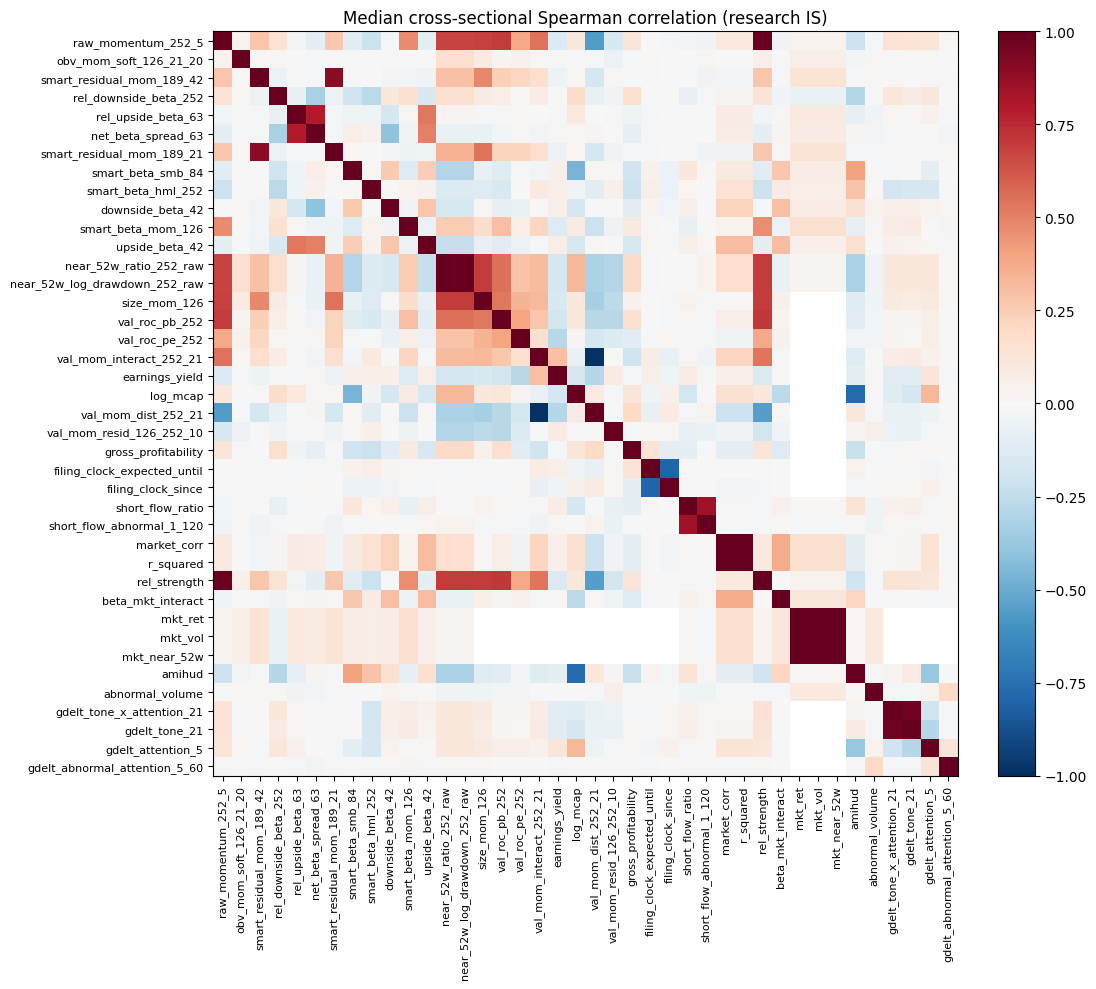

Pairs |rho| >= 0.7: 15
Pairs |rho| >= 0.9: 9


,a,b,rho,abs_rho
711,mkt_ret,mkt_vol,1.000000,1.000000
712,mkt_ret,mkt_near_52w,1.000000,1.000000
669,market_corr,r_squared,1.000000,1.000000
715,mkt_vol,mkt_near_52w,1.000000,1.000000
402,near_52w_ratio_252_raw,near_52w_log_drawdown_252_raw,1.000000,1.000000
28,raw_momentum_252_5,rel_strength,0.989846,0.989846
520,val_mom_interact_252_21,val_mom_dist_252_21,-0.986639,0.986639
729,gdelt_tone_x_attention_21,gdelt_tone_21,0.973547,0.973547
80,smart_residual_mom_189_42,smart_residual_mom_189_21,0.904140,0.904140
642,short_flow_ratio,short_flow_abnormal_1_120,0.840269,0.840269


In [7]:
### 4.2 Median cross-sectional Spearman correlation

def median_cs_spearman(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    mats = []
    for _, grp in frame.groupby("date", sort=False):
        sub = grp[cols]
        if len(sub) < 10:
            continue
        # Pairwise Spearman (NaNs allowed per pair); skip empty cross-sections
        if int(sub.notna().any(axis=1).sum()) < 10:
            continue
        mats.append(sub.corr(method="spearman").to_numpy())
    if not mats:
        raise ValueError("no dates produced a Spearman matrix")
    med = np.nanmedian(np.stack(mats, axis=0), axis=0)
    return pd.DataFrame(med, index=cols, columns=cols)


corr = median_cs_spearman(panel_is, FEATURE_COLS)
print(f"Median CS Spearman matrix: {corr.shape}")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_title("Median cross-sectional Spearman correlation (research IS)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

# Pair table
pairs = []
for i, a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i + 1 :]:
        rho = float(corr.loc[a, b])
        if np.isfinite(rho):
            pairs.append({"a": a, "b": b, "rho": rho, "abs_rho": abs(rho)})
pairs_df = pd.DataFrame(pairs).sort_values("abs_rho", ascending=False)
high = pairs_df.loc[pairs_df["abs_rho"] >= CORR_THRESH_HIGH].copy()
very_high = pairs_df.loc[pairs_df["abs_rho"] >= CORR_THRESH_VERY_HIGH].copy()
print(f"Pairs |rho| >= {CORR_THRESH_HIGH}: {len(high)}")
print(f"Pairs |rho| >= {CORR_THRESH_VERY_HIGH}: {len(very_high)}")
display(high.head(40))


In [8]:
### High-corr clusters (|rho| >= CORR_THRESH_HIGH)

parent = {c: c for c in FEATURE_COLS}


def find(x: str) -> str:
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(a: str, b: str) -> None:
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra


for _, row in high.iterrows():
    union(row["a"], row["b"])

clusters: dict[str, list[str]] = {}
for c in FEATURE_COLS:
    clusters.setdefault(find(c), []).append(c)
multi = {k: sorted(v) for k, v in clusters.items() if len(v) > 1}
print(f"Clusters with size > 1 (threshold={CORR_THRESH_HIGH}): {len(multi)}")
for i, members in enumerate(sorted(multi.values(), key=len, reverse=True), 1):
    print(f"  cluster {i} ({len(members)}): {members}")


Clusters with size > 1 (threshold=0.7): 11
  cluster 1 (3): ['raw_momentum_252_5', 'rel_strength', 'val_roc_pb_252']
  cluster 2 (3): ['mkt_near_52w', 'mkt_ret', 'mkt_vol']
  cluster 3 (2): ['smart_residual_mom_189_21', 'smart_residual_mom_189_42']
  cluster 4 (2): ['net_beta_spread_63', 'rel_upside_beta_63']
  cluster 5 (2): ['near_52w_log_drawdown_252_raw', 'near_52w_ratio_252_raw']
  cluster 6 (2): ['val_mom_dist_252_21', 'val_mom_interact_252_21']
  cluster 7 (2): ['amihud', 'log_mcap']
  cluster 8 (2): ['filing_clock_expected_until', 'filing_clock_since']
  cluster 9 (2): ['short_flow_abnormal_1_120', 'short_flow_ratio']
  cluster 10 (2): ['market_corr', 'r_squared']
  cluster 11 (2): ['gdelt_tone_21', 'gdelt_tone_x_attention_21']


In [9]:
### Post-correlation ditch list
# One survivor per high-corr cluster (prefer better IC / ICIR). Fill before running §4.3 VIF.
# Do not repeat names already in cols_remove_coverage.
cols_remove_corr: list[str] = [
    "r_squared",
    "mkt_vol",
    "mkt_near_52w",
    "rel_strength",
    "val_mom_interact_252_21",
    "gdelt_tone_21",
    "smart_residual_mom_189_21",
    "short_flow_abnormal_1_120",
    "net_beta_spread_63",
    "filing_clock_since",
    "amihud",
    "near_52w_log_drawdown_252_raw",
]

_overlap_corr = sorted(set(cols_remove_corr) & set(cols_remove_coverage))
if _overlap_corr:
    raise ValueError(
        "cols_remove_corr overlaps cols_remove_coverage (use extras only): "
        f"{_overlap_corr}"
    )
_unknown_corr = [c for c in cols_remove_corr if c not in FEATURE_COLS]
if _unknown_corr:
    raise ValueError(f"cols_remove_corr not in FEATURE_COLS: {_unknown_corr}")
print(f"cols_remove_corr ({len(cols_remove_corr)}): {cols_remove_corr}")

cols_remove_corr (12): ['r_squared', 'mkt_vol', 'mkt_near_52w', 'rel_strength', 'val_mom_interact_252_21', 'gdelt_tone_21', 'smart_residual_mom_189_21', 'short_flow_abnormal_1_120', 'net_beta_spread_63', 'filing_clock_since', 'amihud', 'near_52w_log_drawdown_252_raw']


### 4.3 VIF

The **Variance Inflation Factor (VIF)** measures how much the variance (and standard error) of an estimated regression coefficient is increased because of collinearity (statistical dependence) with other predictor variables.

| VIF | Guidance |
|-----|----------|
| **&lt; 5** | Generally fine |
| **5 ≤ VIF &lt; 10** | Consider dropping / choosing one from the cluster |
| **VIF ≥ 10** | Strong multicollinearity — prefer dropping before GBM |

Computed on IS rows with complete coverage over the **post-coverage / post-corr** column set (excludes `cols_remove_coverage` and `cols_remove_corr`), via $VIF_j = 1 / (1 - R^2_j)$ from OLS of feature $j$ on the others. Fill `cols_remove_vif` with *extra* drops only (no overlap with earlier stage lists).

**ICIR watchlist (not auto-ditched):** near-52w ratio vs log_drawdown; weak |ICIR| smart betas / earnings_yield / downside_beta_42; strong negative IC `smart_beta_hml_252`.

In [10]:
### 4.3 VIF on complete IS rows

def vif_table(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    X = frame[cols].astype(float)
    X = X.dropna(how="any")
    if len(X) < len(cols) + 5:
        raise ValueError(
            f"too few complete rows for VIF: {len(X)} rows, {len(cols)} cols"
        )
    # demean for numerical stability (intercept absorbed)
    Xc = X - X.mean(axis=0)
    rows = []
    arr = Xc.to_numpy()
    for j, name in enumerate(cols):
        y = arr[:, j]
        others = np.delete(arr, j, axis=1)
        # least squares: y ~ others
        beta, *_ = np.linalg.lstsq(others, y, rcond=None)
        fitted = others @ beta
        ss_res = float(np.sum((y - fitted) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        r2 = min(max(r2, 0.0), 0.999999)
        vif = 1.0 / (1.0 - r2)
        if vif < 5:
            flag = "ok"
        elif vif < 10:
            flag = "consider_drop"
        else:
            flag = "prefer_drop"
        rows.append({"feature": name, "vif": vif, "r2_others": r2, "flag": flag})
    return pd.DataFrame(rows).sort_values("vif", ascending=False)


vif_cols = [
    c
    for c in FEATURE_COLS
    if c not in set(cols_remove_coverage) | set(cols_remove_corr)
]
if len(vif_cols) < 2:
    raise ValueError(f"too few columns left for VIF after stage drops: {vif_cols}")

vif_df = vif_table(panel_is, vif_cols)
print(
    f"VIF on {len(vif_cols)} cols after excluding "
    f"coverage={len(cols_remove_coverage)} corr={len(cols_remove_corr)}"
)
print(f"VIF rows used (complete cases): {panel_is[vif_cols].dropna().shape[0]:,}")
display(vif_df)


VIF on 28 cols after excluding coverage=0 corr=12
VIF rows used (complete cases): 14,378


,feature,vif,r2_others,flag
22,beta_mkt_interact,9.922547,0.899219,consider_drop
23,mkt_ret,9.887009,0.898857,consider_drop
0,raw_momentum_252_5,3.852964,0.740460,ok
11,size_mom_126,3.017692,0.668621,ok
10,near_52w_ratio_252_raw,3.007638,0.667513,ok
16,val_mom_dist_252_21,2.263126,0.558133,ok
15,log_mcap,2.205802,0.546650,ok
9,upside_beta_42,2.006447,0.501607,ok
14,earnings_yield,1.818981,0.450242,ok
12,val_roc_pb_252,1.691711,0.408882,ok


In [11]:
### Post-VIF ditch list
# Extra drops after re-running VIF on the post-corr (and post-coverage) column set.
# Do not repeat names already in cols_remove_coverage or cols_remove_corr.
cols_remove_vif: list[str] = [
    "mkt_ret"
]

_overlap_vif = sorted(
    set(cols_remove_vif) & (set(cols_remove_coverage) | set(cols_remove_corr))
)
if _overlap_vif:
    raise ValueError(
        "cols_remove_vif overlaps earlier stage lists (use extras only): "
        f"{_overlap_vif}"
    )
_unknown_vif = [c for c in cols_remove_vif if c not in FEATURE_COLS]
if _unknown_vif:
    raise ValueError(f"cols_remove_vif not in FEATURE_COLS: {_unknown_vif}")
print(f"cols_remove_vif ({len(cols_remove_vif)}): {cols_remove_vif}")

cols_remove_vif (1): ['mkt_ret']


## 5. Drop + export

Union the staged ditch lists from §4 into `cols_to_remove`, print the removals by stage, then write the **full-sample** matrix (keys + OHLCV/`fwd_ret_*` context + kept engineered factors) to `01_data/data_files/s1_equities/s1_engineered_features.parquet`.

Re-run only this section after updating the stage lists; no need to rebuild features if the raw cache is warm.


In [12]:
stage_lists = [
    ("coverage", cols_remove_coverage),
    ("correlation", cols_remove_corr),
    ("vif", cols_remove_vif),
]

# Fail loudly on cross-stage duplicates (each factor should appear in at most one list).
_seen: dict[str, str] = {}
_dup_rows: list[dict[str, str]] = []
for stage, cols in stage_lists:
    for c in cols:
        if c in _seen:
            _dup_rows.append({"feature": c, "first_stage": _seen[c], "also_in": stage})
        else:
            _seen[c] = stage
if _dup_rows:
    display(pd.DataFrame(_dup_rows))
    raise ValueError(
        "staged ditch lists overlap — keep each factor in exactly one stage list"
    )

cols_to_remove = list(_seen.keys())  # insertion order: coverage -> corr -> vif
unknown = [c for c in cols_to_remove if c not in FEATURE_COLS]
if unknown:
    raise ValueError(f"cols_to_remove not in FEATURE_COLS: {unknown}")

removal_df = pd.DataFrame(
    [
        {"stage": stage, "feature": c}
        for stage, cols in stage_lists
        for c in cols
    ]
)
print(
    f"cols_to_remove: {len(cols_to_remove)} unique "
    f"(coverage={len(cols_remove_coverage)}, "
    f"corr={len(cols_remove_corr)}, vif={len(cols_remove_vif)})"
)
if removal_df.empty:
    print("(no factors flagged for removal)")
else:
    display(removal_df)
    print("cols_to_remove =")
    for c in cols_to_remove:
        print(f"  - {c}")

keep_cols = [c for c in FEATURE_COLS if c not in set(cols_to_remove)]
missing_ctx = [c for c in CONTEXT_COLS if c not in panel.columns]
if missing_ctx:
    raise ValueError(f"export missing context cols: {missing_ctx}")
out = panel.loc[:, KEY_COLS + CONTEXT_COLS + keep_cols].copy()
out["date"] = pd.to_datetime(out["date"])
out["feature_date"] = pd.to_datetime(out["feature_date"])

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
out.to_parquet(OUTPUT_PATH, index=False)

print(f"Wrote {OUTPUT_PATH}")
print(f"rows={len(out):,}  cols={list(out.columns)}")
print(f"kept={len(keep_cols)}  removed={len(cols_to_remove)}")
print(
    f"date span: {out['date'].min().date()} -> {out['date'].max().date()}  "
    f"(IS dates={out['date'].isin(train_dates).sum():,} rows)"
)
out.head()


cols_to_remove: 13 unique (coverage=0, corr=12, vif=1)


,stage,feature
0,correlation,r_squared
1,correlation,mkt_vol
2,correlation,mkt_near_52w
3,correlation,rel_strength
4,correlation,val_mom_interact_252_21
5,correlation,gdelt_tone_21
6,correlation,smart_residual_mom_189_21
7,correlation,short_flow_abnormal_1_120
8,correlation,net_beta_spread_63
9,correlation,filing_clock_since


cols_to_remove =
  - r_squared
  - mkt_vol
  - mkt_near_52w
  - rel_strength
  - val_mom_interact_252_21
  - gdelt_tone_21
  - smart_residual_mom_189_21
  - short_flow_abnormal_1_120
  - net_beta_spread_63
  - filing_clock_since
  - amihud
  - near_52w_log_drawdown_252_raw
  - mkt_ret
Wrote c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
rows=410,594  cols=['date', 'ticker', 'feature_date', 'open', 'high', 'low', 'close', 'volume', 'fwd_ret_1', 'fwd_ret_5', 'fwd_ret_21', 'raw_momentum_252_5', 'obv_mom_soft_126_21_20', 'smart_residual_mom_189_42', 'rel_downside_beta_252', 'rel_upside_beta_63', 'smart_beta_smb_84', 'smart_beta_hml_252', 'downside_beta_42', 'smart_beta_mom_126', 'upside_beta_42', 'near_52w_ratio_252_raw', 'size_mom_126', 'val_roc_pb_252', 'val_roc_pe_252', 'earnings_yield', 'log_mcap', 'val_mom_dist_252_21', 'val_mom_resid_126_252_10', 'gross_profitability', 'filing_clock_expected_un

,date,ticker,feature_date,open,high,low,close,volume,fwd_ret_1,fwd_ret_5,...,val_mom_resid_126_252_10,gross_profitability,filing_clock_expected_until,short_flow_ratio,market_corr,beta_mkt_interact,abnormal_volume,gdelt_tone_x_attention_21,gdelt_attention_5,gdelt_abnormal_attention_5_60
0,2010-01-05,AAPL,2010-01-04,6.424143,6.421146,6.357683,6.406478,493729600.0,-0.001025,-0.025210,...,NaN,NaN,27.0,0.439729,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-06,AAPL,2010-01-05,6.417558,6.453779,6.383729,6.417557,601904800.0,-0.012268,-0.030367,...,NaN,NaN,26.0,0.412976,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-07,AAPL,2010-01-06,6.338825,6.443003,6.308892,6.315478,552160000.0,-0.006848,-0.007745,...,NaN,NaN,25.0,0.340286,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-08,AAPL,2010-01-07,6.295419,6.346309,6.258000,6.303801,477131200.0,0.011888,0.002996,...,NaN,NaN,24.0,0.336569,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-11,AAPL,2010-01-08,6.370258,6.346310,6.258300,6.345711,447610800.0,-0.016965,-0.021005,...,NaN,NaN,21.0,0.464046,NaN,NaN,NaN,NaN,NaN,NaN
